[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/02_core_deep_learning/07_transfer_learning/transfer_learning.ipynb)


# 07 . Transfer Learning

## Concept — Transfer learning (revision notes)

**What it is**
- Reusing a model trained on one task (the *source*, usually large) as the starting point for another (the *target*, usually small). The pretrained **backbone** supplies general features; a new task-specific **head** is trained on top.
- Two main strategies: **feature extraction** (freeze the backbone, train only the new head) and **fine-tuning** (continue training some or all backbone weights, typically with a smaller learning rate).

**Why it matters**
- Training from scratch needs lots of labelled data and compute. Pretrained features already encode useful structure (edges, textures, syntax...), so a handful of target examples can be enough.
- This is how nearly all modern vision and NLP systems are built.

**When to use**
- Small target dataset + a related, large source task: it helps most. Very different domains: fine-tune more layers, or expect little benefit ("negative transfer" is possible).
- Rule of thumb: little data and similar domain -> freeze; more data or different domain -> fine-tune (with a small LR).

**Math & intuition**
- Freezing = `p.requires_grad_(False)`; frozen parameters get no gradient, so pass only trainable ones to the optimizer.
- Early layers learn generic features, late layers task-specific ones, so a common recipe is *discriminative learning rates*: tiny LR for the backbone, larger for the new head.
- **BatchNorm trap**: `requires_grad=False` does NOT stop BatchNorm's running statistics from updating in `train()` mode. Put frozen BN layers in `eval()`.
- In this notebook there is no internet and no torchvision, so we **build our own "pretrained" backbone**: a small CNN trained on a synthetic source task, then transferred to a new synthetic target task. The mechanics are identical to loading ImageNet weights.


### 1. Two synthetic domains: a source task and a related target task

**What this cell does (plain language):** we generate 16x16 noisy images containing one 7x7 stroke pattern. The **source** task has 8 classes (bars, diagonals, plus, box, X, filled square). The **target** task has 3 *new* classes (L, T, Z shapes) built from the same kinds of strokes. Shared low-level structure is exactly what makes transfer possible.

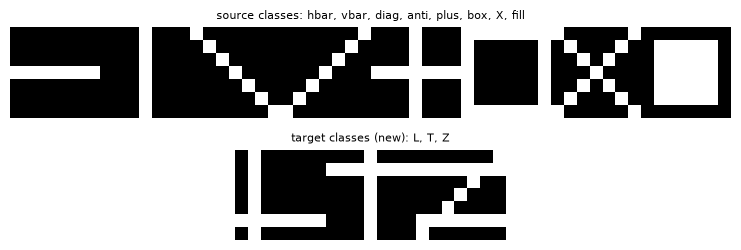

source train (1500, 1, 16, 16) | target test (600, 1, 16, 16)


In [1]:
import io, copy, math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
S = 7
def pat(name):
    p = torch.zeros(S, S)
    if   name == "hbar": p[3, :] = 1
    elif name == "vbar": p[:, 3] = 1
    elif name == "diag": p += torch.eye(S)
    elif name == "anti": p += torch.eye(S).flip(1)
    elif name == "plus": p[3, :] = 1; p[:, 3] = 1
    elif name == "box":  p[0, :] = p[-1, :] = 1; p[:, 0] = p[:, -1] = 1
    elif name == "X":    p += torch.eye(S) + torch.eye(S).flip(1)
    elif name == "fill": p[1:6, 1:6] = 1
    elif name == "L":    p[:, 1] = 1; p[-2, :] = 1
    elif name == "T":    p[1, :] = 1; p[:, 3] = 1
    elif name == "Z":    p[1, :] = 1; p[-2, :] = 1; p += torch.eye(S).flip(1)
    return p.clamp(max=1)

SRC = ["hbar", "vbar", "diag", "anti", "plus", "box", "X", "fill"]
TGT = ["L", "T", "Z"]

def make(names, n, seed, size=16, noise=0.3, scale=1.0):
    g = torch.Generator().manual_seed(seed)
    P = torch.stack([pat(k) for k in names])
    y = torch.randint(0, len(names), (n,), generator=g)
    x = torch.randn(n, 1, size, size, generator=g) * noise
    for i in range(n):
        r, c = torch.randint(0, size - S + 1, (2,), generator=g).tolist()
        x[i, 0, r:r+S, c:c+S] += P[y[i]]
    return x * scale, y

Xsrc, ysrc = make(SRC, 1500, seed=0)
Xsrc_te, ysrc_te = make(SRC, 500, seed=9)
Xtgt_te, ytgt_te = make(TGT, 600, seed=5)
fig, axes = plt.subplots(2, 1, figsize=(10, 2.6))
axes[0].imshow(torch.cat([pat(k) for k in SRC], 1), cmap="gray"); axes[0].set_title("source classes: " + ", ".join(SRC), fontsize=8)
axes[1].imshow(torch.cat([pat(k) for k in TGT], 1), cmap="gray"); axes[1].set_title("target classes (new): " + ", ".join(TGT), fontsize=8)
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()
print("source train", tuple(Xsrc.shape), "| target test", tuple(Xtgt_te.shape))

### 2. Model = backbone + head; 'pretrain' on the source task

**What this cell does (plain language):** we define a network split into a `backbone` (three conv blocks + global pooling -> a 32-d embedding) and a `head` (one linear layer). Splitting the model this way is what makes transfer easy. We train it on the source task, evaluate, and save the backbone weights into an in-memory checkpoint, as you would save a downloaded pretrained model.

In [2]:
def conv_block(a, b):
    return nn.Sequential(nn.Conv2d(a, b, 3, padding=1, bias=False), nn.BatchNorm2d(b), nn.ReLU(), nn.MaxPool2d(2))

class Net(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.backbone = nn.Sequential(conv_block(1, 8), conv_block(8, 16), conv_block(16, 32),
                                      nn.AdaptiveAvgPool2d(1), nn.Flatten())     # -> (N, 32) embedding
        self.head = nn.Linear(32, n_classes)
    def forward(self, x): return self.head(self.backbone(x))

def accuracy(model, X, y):
    model.eval()
    with torch.no_grad(): return (model(X).argmax(1) == y).float().mean().item()

def fit(model, X, y, epochs, optimizer, bs=32, keep_frozen_bn_eval=False):
    for ep in range(epochs):
        model.train()
        if keep_frozen_bn_eval: model.backbone.eval()        # see section 4
        perm = torch.randperm(len(X))
        for i in range(0, len(X), bs):
            idx = perm[i:i+bs]
            optimizer.zero_grad(); F.cross_entropy(model(X[idx]), y[idx]).backward(); optimizer.step()
    return model

torch.manual_seed(0)
pretrained = Net(len(SRC))
fit(pretrained, Xsrc, ysrc, 8, torch.optim.Adam(pretrained.parameters(), lr=3e-3))
print("source-task test accuracy:", round(accuracy(pretrained, Xsrc_te, ysrc_te), 3))

ckpt = io.BytesIO(); torch.save(pretrained.backbone.state_dict(), ckpt); ckpt.seek(0)   # stand-in for a downloaded file
print("checkpoint size (bytes):", ckpt.getbuffer().nbytes)

source-task test accuracy: 0.998
checkpoint size (bytes): 30253


### 3. Loading pretrained weights into a new model (and the head mismatch error)

**What this cell does (plain language):** we load the checkpoint into a fresh model for the 3-class target task. Loading the *whole* state dict of the source model into the new model fails because the head shapes differ (8 vs 3 outputs); the standard fix is to load only the backbone. `strict=False` reports which keys were skipped, which is the safe way to check what actually loaded.

In [3]:
def new_target_model(load_backbone=True, seed=0):
    torch.manual_seed(seed)
    m = Net(len(TGT))                                  # new head: 3 outputs, randomly initialized
    if load_backbone:
        ckpt.seek(0); m.backbone.load_state_dict(torch.load(ckpt))
    return m

# wrong: load the full source state_dict (including the 8-way head)
try:
    Net(3).load_state_dict(pretrained.state_dict())
except RuntimeError as e:
    print("full state_dict load failed:", str(e).splitlines()[1].strip()[:90])

# right: only the backbone; verify the weights really transferred
m = new_target_model()
same = all(torch.equal(a, b) for a, b in zip(m.backbone.state_dict().values(), pretrained.backbone.state_dict().values()))
print("backbone weights identical to pretrained:", same)
# alternatively: filter by key prefix and use strict=False to see what was skipped
res = Net(3).load_state_dict({k: v for k, v in pretrained.state_dict().items() if k.startswith("backbone")}, strict=False)
print("missing keys:", res.missing_keys, "| unexpected:", res.unexpected_keys)

full state_dict load failed: size mismatch for head.weight: copying a param with shape torch.Size([8, 32]) from checkpo
backbone weights identical to pretrained: True
missing keys: ['head.weight', 'head.bias'] | unexpected: []


### 4. Freezing correctly: requires_grad, the optimizer, and the BatchNorm trap

**What this cell does (plain language):** we freeze the backbone, count trainable parameters, build an optimizer from only the trainable ones, and train. Then we check two things: the frozen *weights* are unchanged (good), but BatchNorm *running statistics* changed anyway because the layer was in `train()` mode (the trap). Putting the frozen backbone in `eval()` fixes it.

In [4]:
def freeze(module):
    for p in module.parameters(): p.requires_grad_(False)

def n_trainable(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)
def n_total(model): return sum(p.numel() for p in model.parameters())

Xt, yt = make(TGT, 60, seed=1)                      # a small labelled target set: 60 images

m = new_target_model(); freeze(m.backbone)
print(f"trainable params: {n_trainable(m)} of {n_total(m)}")

w_before = m.backbone[0][0].weight.clone()
bn = m.backbone[0][1]; rm_before = bn.running_mean.clone()
opt = torch.optim.Adam([p for p in m.parameters() if p.requires_grad], lr=3e-3)   # only trainable params
fit(m, Xt, yt, 5, opt)                                                            # model.train() everywhere
print("frozen conv weight unchanged:        ", torch.equal(w_before, m.backbone[0][0].weight))
print("BN running_mean unchanged (trap!):   ", torch.equal(rm_before, bn.running_mean), "<- changed although frozen")

m2 = new_target_model(); freeze(m2.backbone)
rm2 = m2.backbone[0][1].running_mean.clone()
opt2 = torch.optim.Adam(m2.head.parameters(), lr=3e-3)
fit(m2, Xt, yt, 5, opt2, keep_frozen_bn_eval=True)                                # backbone stays in eval()
print("with backbone.eval(): BN running_mean unchanged:", torch.equal(rm2, m2.backbone[0][1].running_mean))

trainable params: 99 of 6043
frozen conv weight unchanged:         True
BN running_mean unchanged (trap!):    False <- changed although frozen
with backbone.eval(): BN running_mean unchanged: True


### 5. Feature extraction: cache embeddings, train only a linear probe

**What this cell does (plain language):** if the backbone is frozen (and in eval mode) its output for each image never changes, so we can run the backbone ONCE under `no_grad`, store the 32-d embeddings, and train a tiny linear classifier on them in a fraction of the time. This 'linear probe' is also the standard way to measure how good a representation is.

In [5]:
def embed(backbone, X):
    backbone.eval()
    with torch.no_grad(): return backbone(X)

m = new_target_model()
Ztr, Zte = embed(m.backbone, Xt), embed(m.backbone, Xtgt_te)         # (60, 32) and (600, 32)
print("embeddings:", tuple(Ztr.shape), tuple(Zte.shape))

torch.manual_seed(0)
probe = nn.Linear(32, 3); opt = torch.optim.Adam(probe.parameters(), lr=1e-2)
for step in range(300):                                              # full-batch training on cached features
    opt.zero_grad(); F.cross_entropy(probe(Ztr), yt).backward(); opt.step()
with torch.no_grad(): probe_acc = (probe(Zte).argmax(1) == ytgt_te).float().mean().item()
print(f"linear probe on pretrained features: target test acc = {probe_acc:.3f} (chance = 0.333)")

# same probe on RANDOM (untrained) backbone features: does pretraining matter?
rand = new_target_model(load_backbone=False)
Zr_tr, Zr_te = embed(rand.backbone, Xt), embed(rand.backbone, Xtgt_te)
torch.manual_seed(0); probe_r = nn.Linear(32, 3); opt = torch.optim.Adam(probe_r.parameters(), lr=1e-2)
for step in range(300):
    opt.zero_grad(); F.cross_entropy(probe_r(Zr_tr), yt).backward(); opt.step()
with torch.no_grad(): print("linear probe on random-init features:   target test acc =", round((probe_r(Zr_te).argmax(1) == ytgt_te).float().mean().item(), 3))

embeddings: (60, 32) (600, 32)


linear probe on pretrained features: target test acc = 0.883 (chance = 0.333)


linear probe on random-init features:   target test acc = 0.525


### 6. Fine-tuning with discriminative learning rates (parameter groups)

**What this cell does (plain language):** instead of freezing, we update everything but give the pretrained backbone a smaller learning rate than the freshly initialized head, using optimizer *parameter groups*. The idea: the backbone is already good, so nudge it gently; the random head must learn fast.

In [6]:
m = new_target_model()
opt = torch.optim.Adam([
    {"params": m.backbone.parameters(), "lr": 3e-4},     # gentle updates for pretrained layers
    {"params": m.head.parameters(),     "lr": 3e-3},     # faster for the new head
])
for g in opt.param_groups: print("group lr:", g["lr"], "| #params:", sum(p.numel() for p in g["params"]))
fit(m, Xt, yt, 30, opt)
print("fine-tuned (discriminative LR) target test acc:", round(accuracy(m, Xtgt_te, ytgt_te), 3))

group lr: 0.0003 | #params: 5944
group lr: 0.003 | #params: 99


fine-tuned (discriminative LR) target test acc: 0.85


### 7. Gradual unfreezing

**What this cell does (plain language):** a common recipe: train only the head first (so the random head does not send garbage gradients into good features), then unfreeze the last backbone block, then everything. We implement it with a small helper that toggles `requires_grad`, and print the trainable parameter counts at each phase. Parameters with `requires_grad=False` get `grad=None` and the optimizer skips them, so one optimizer can be created up front.

In [7]:
m = new_target_model()
blocks = [m.backbone[0], m.backbone[1], m.backbone[2]]        # conv blocks, shallow -> deep
for b in blocks: freeze(b)
all_params = [p for p in m.parameters()]
opt = torch.optim.Adam([{"params": m.head.parameters(), "lr": 3e-3},
                        {"params": [p for b in blocks for p in b.parameters()], "lr": 3e-4}])

def phase(name, epochs, unfreeze=()):
    for b in unfreeze:
        for p in b.parameters(): p.requires_grad_(True)
    fit(m, Xt, yt, epochs, opt)
    print(f"{name:34s} trainable {n_trainable(m):5d}/{n_total(m)} | target test acc {accuracy(m, Xtgt_te, ytgt_te):.3f}")

phase("phase 1: head only", 10)
phase("phase 2: + last conv block", 10, unfreeze=[blocks[2]])
phase("phase 3: + all blocks", 10, unfreeze=[blocks[1], blocks[0]])

phase 1: head only                 trainable    99/6043 | target test acc 0.433
phase 2: + last conv block         trainable  4771/6043 | target test acc 0.722


phase 3: + all blocks              trainable  6043/6043 | target test acc 0.883


### 8. Scratch vs frozen vs fine-tuned, across target-set sizes

**What this cell does (plain language):** we compare four strategies for several numbers of labelled target images, averaging over 3 random target subsets to reduce noise: training from scratch, frozen backbone (linear head only), and fine-tuning the whole pretrained model. Read the table honestly: transfer helps most when data is scarce, but the gap and the ranking can vary with the budget and the seed.

 #target imgs |      10 |      30 |     100
      scratch |   0.374 |   0.456 |   0.822
       frozen |   0.615 |   0.728 |   0.870
     finetune |   0.604 |   0.832 |   0.943


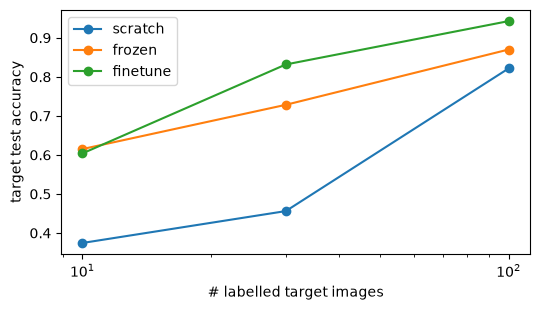

In [8]:
def run_strategy(strategy, n, seed):
    Xs_, ys_ = make(TGT, n, seed=100 + seed)
    torch.manual_seed(seed)
    if strategy == "scratch":
        m = new_target_model(load_backbone=False, seed=seed)
        opt = torch.optim.Adam(m.parameters(), lr=3e-3); fit(m, Xs_, ys_, 40, opt)
    elif strategy == "frozen":
        m = new_target_model(seed=seed); freeze(m.backbone)
        opt = torch.optim.Adam(m.head.parameters(), lr=3e-3); fit(m, Xs_, ys_, 40, opt, keep_frozen_bn_eval=True)
    else:  # finetune
        m = new_target_model(seed=seed)
        opt = torch.optim.Adam([{"params": m.backbone.parameters(), "lr": 1e-3}, {"params": m.head.parameters(), "lr": 3e-3}])
        fit(m, Xs_, ys_, 40, opt)
    return accuracy(m, Xtgt_te, ytgt_te)

sizes, strategies = (10, 30, 100), ("scratch", "frozen", "finetune")
table = {s: [sum(run_strategy(s, n, seed) for seed in range(3)) / 3 for n in sizes] for s in strategies}
print(f"{'#target imgs':>13} | " + " | ".join(f"{n:>7}" for n in sizes))
for s in strategies: print(f"{s:>13} | " + " | ".join(f"{a:7.3f}" for a in table[s]))
plt.figure(figsize=(5.5, 3.2))
for s in strategies: plt.plot(sizes, table[s], "o-", label=s)
plt.xscale("log"); plt.xlabel("# labelled target images"); plt.ylabel("target test accuracy"); plt.legend(); plt.tight_layout(); plt.show()

### 9. Looking at the embeddings (PCA)

**What this cell does (plain language):** we project the 32-d embeddings of target test images to 2D with PCA (via `torch.pca_lowrank`) for a random backbone and for the source-pretrained backbone, coloured by class. Better-separated clusters mean a linear head has an easier job.

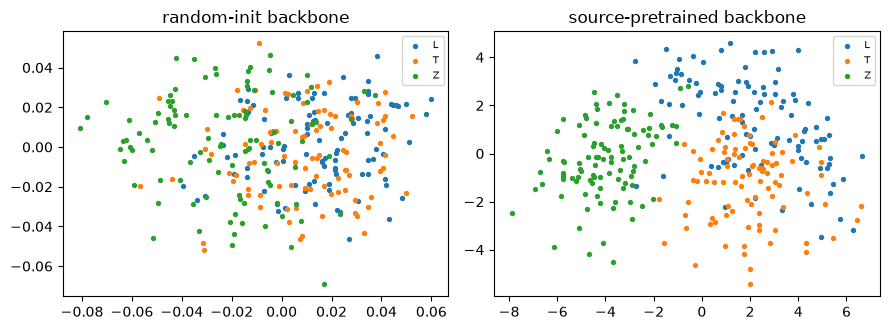

In [9]:
def pca2(Z):
    Zc = Z - Z.mean(0)
    U, Sv, V = torch.pca_lowrank(Zc, q=2, center=False)
    return Zc @ V[:, :2]

idx = torch.arange(300)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for a, (title, bb) in zip(ax, (("random-init backbone", rand.backbone), ("source-pretrained backbone", new_target_model().backbone))):
    pts = pca2(embed(bb, Xtgt_te[idx]))
    for c in range(3): a.scatter(*pts[ytgt_te[idx] == c].T, s=8, label=TGT[c])
    a.set_title(title); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

### 10. Catastrophic forgetting

**What this cell does (plain language):** fine-tuning changes the backbone, so it can lose what it knew about the source task. We keep a copy of the original 8-way source head, fine-tune the backbone on the target task, and then re-attach the old head to see how much source accuracy was lost. If you need both tasks, freeze more, use a lower LR, or mix source data in.

In [10]:
src_head = copy.deepcopy(pretrained.head)                    # remember the original source head
m = new_target_model()
print("source accuracy BEFORE fine-tuning:", round(accuracy(nn.Sequential(m.backbone, src_head), Xsrc_te, ysrc_te), 3))
opt = torch.optim.Adam([{"params": m.backbone.parameters(), "lr": 3e-3}, {"params": m.head.parameters(), "lr": 3e-3}])
Xbig, ybig = make(TGT, 300, seed=7)
fit(m, Xbig, ybig, 15, opt)
print("target accuracy after fine-tuning:  ", round(accuracy(m, Xtgt_te, ytgt_te), 3))
print("source accuracy AFTER fine-tuning:  ", round(accuracy(nn.Sequential(m.backbone, src_head), Xsrc_te, ysrc_te), 3), "(old head on the changed backbone)")

source accuracy BEFORE fine-tuning: 0.998


target accuracy after fine-tuning:   1.0
source accuracy AFTER fine-tuning:   0.69 (old head on the changed backbone)


### 11. Input-preprocessing mismatch

**What this cell does (plain language):** a pretrained model expects inputs prepared exactly as during pretraining (same scale, same normalization). We feed the same target test images at a different intensity scale and see the *pretrained+frozen* pipeline degrade; this is why pretrained image models ship with a specific mean/std.

In [11]:
m = new_target_model(); freeze(m.backbone)
opt = torch.optim.Adam(m.head.parameters(), lr=3e-3)
fit(m, Xt, yt, 30, opt, keep_frozen_bn_eval=True)
for scale in (1.0, 0.5, 3.0):
    Xs_, ys_ = make(TGT, 600, seed=5, scale=scale)
    print(f"test images scaled x{scale}: accuracy {accuracy(m, Xs_, ys_):.3f}")
print("(train and test must use the same preprocessing; with BN in eval mode the stored statistics assume the original scale)")

test images scaled x1.0: accuracy 0.758
test images scaled x0.5: accuracy 0.350
test images scaled x3.0: accuracy 0.402
(train and test must use the same preprocessing; with BN in eval mode the stored statistics assume the original scale)


## Common bugs

- **Frozen layers still change because of BatchNorm**
  `requires_grad=False` freezes weights but BN running mean/var keep updating in `train()` mode, silently drifting the "frozen" features. Fix: call `.eval()` on the frozen backbone after every `model.train()` (see section 4), or override `train()` in your model.

- **Passing all parameters (including frozen ones) with weight decay**
  Frozen params have `grad=None` and are skipped by most optimizers, but it clutters param groups and some optimizers (or custom code) break. Fix: build the optimizer from `filter(lambda p: p.requires_grad, model.parameters())`.

- **Freezing after creating the optimizer and expecting it to rebuild**
  Optimizers hold references to the parameters you gave them; toggling `requires_grad` later works (grads become `None`), but *adding* new trainable params needs `optimizer.add_param_group`. Fix: plan which params go in which group.

- **Loading a checkpoint with a different head size**
  `load_state_dict` raises a size-mismatch error. Fix: load only backbone keys, or `strict=False` and then inspect `missing_keys`/`unexpected_keys` - never silently ignore them.

- **Same learning rate for backbone and head**
  A large LR destroys pretrained features in the first few steps (a randomly initialized head produces huge, meaningless gradients). Fix: smaller LR for the backbone (e.g. 10x), or train the head first.

- **Different preprocessing than pretraining**
  Wrong scale/normalization/channel order makes pretrained features meaningless. Fix: reuse the exact preprocessing pipeline of the pretrained model.

- **Evaluating without `model.eval()`**
  BN and dropout behave differently and results fluctuate. Fix: `eval()` + `no_grad()` for any evaluation or feature caching.

- **Caching features while augmenting data**
  Cached embeddings are fixed, so random augmentations are frozen in too. Fix: cache only without augmentation, or run the backbone online if you need fresh augmentations.

- **Assuming transfer always helps**
  With very different source/target domains, pretrained features can be useless or harmful (negative transfer). Fix: always include a from-scratch baseline and a linear-probe baseline.

- **Forgetting that fine-tuning forgets**
  The backbone drifts away from the source task (catastrophic forgetting). Fix: lower LR, freeze early layers, or keep a copy of the original model for the source task.


## Exercises

Attempt each one in the empty cell right after the question. A full solution is in the cell after that - don't peek until you've tried.

**Exercise 1 - Count trainable parameters.**
Freeze the backbone of a `Net(3)` and compute the percentage of parameters that remain trainable.

In [12]:
# Your attempt for Exercise 1 here


**Solution 1**

In [13]:
# Solution 1
m = Net(3); freeze(m.backbone)
print(n_trainable(m), n_total(m), f"{100*n_trainable(m)/n_total(m):.1f}%")

99 6043 1.6%


**Exercise 2 - Freeze by name.**
Freeze every parameter whose name starts with `backbone.0` (the first conv block) using `named_parameters()` and list which names remain trainable.

In [14]:
# Your attempt for Exercise 2 here


**Solution 2**

In [15]:
# Solution 2
m = Net(3)
for n, p in m.named_parameters():
    if n.startswith("backbone.0"): p.requires_grad_(False)
print([n for n, p in m.named_parameters() if p.requires_grad])

['backbone.1.0.weight', 'backbone.1.1.weight', 'backbone.1.1.bias', 'backbone.2.0.weight', 'backbone.2.1.weight', 'backbone.2.1.bias', 'head.weight', 'head.bias']


**Exercise 3 - Replace the head.**
Replace `m.head` by a two-layer head (`Linear(32,16)`, ReLU, `Linear(16,3)`) and check the output shape on a batch. Which parameters are new?

In [16]:
# Your attempt for Exercise 3 here


**Solution 3**

In [17]:
# Solution 3
m = new_target_model()
m.head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 3))
print(m(Xtgt_te[:5]).shape, [n for n, _ in m.head.named_parameters()])

torch.Size([5, 3]) ['0.weight', '0.bias', '2.weight', '2.bias']


**Exercise 4 - Verify the frozen backbone is really frozen.**
Train a frozen-backbone model for a few epochs (with `keep_frozen_bn_eval=True`) and assert that EVERY tensor in the backbone `state_dict()` (including BN buffers) is unchanged.

In [18]:
# Your attempt for Exercise 4 here


**Solution 4**

In [19]:
# Solution 4
m = new_target_model(); freeze(m.backbone)
before = {k: v.clone() for k, v in m.backbone.state_dict().items()}
fit(m, Xt, yt, 3, torch.optim.Adam(m.head.parameters(), lr=3e-3), keep_frozen_bn_eval=True)
print(all(torch.equal(before[k], v) for k, v in m.backbone.state_dict().items()))

True


**Exercise 5 - Add a parameter group later.**
Start with an optimizer holding only the head, then unfreeze the last backbone block and add it with `optimizer.add_param_group` at a lower LR.

In [20]:
# Your attempt for Exercise 5 here


**Solution 5**

In [21]:
# Solution 5
m = new_target_model(); freeze(m.backbone)
opt = torch.optim.Adam(m.head.parameters(), lr=3e-3)
for p in m.backbone[2].parameters(): p.requires_grad_(True)
opt.add_param_group({"params": m.backbone[2].parameters(), "lr": 3e-4})
print([g["lr"] for g in opt.param_groups], n_trainable(m))

[0.003, 0.0003] 4771


**Exercise 6 - Linear probe vs fine-tune.**
On 30 target images, compare the target test accuracy of a linear probe on cached features against whole-model fine-tuning. Which is better here and why might that change with 3000 images?

In [22]:
# Your attempt for Exercise 6 here


**Solution 6**

In [23]:
# Solution 6
Xs_, ys_ = make(TGT, 30, seed=3)
m = new_target_model(); Z, Zte = embed(m.backbone, Xs_), embed(m.backbone, Xtgt_te)
torch.manual_seed(0); pr = nn.Linear(32, 3); o = torch.optim.Adam(pr.parameters(), lr=1e-2)
for _ in range(300): o.zero_grad(); F.cross_entropy(pr(Z), ys_).backward(); o.step()
print("probe:", (pr(Zte).argmax(1) == ytgt_te).float().mean().item())
m2 = new_target_model(); fit(m2, Xs_, ys_, 40, torch.optim.Adam(m2.parameters(), lr=1e-3))
print("fine-tune:", accuracy(m2, Xtgt_te, ytgt_te))

probe: 0.925000011920929


fine-tune: 0.7599999904632568


**Exercise 7 - Layer-wise learning rates.**
Give each of the three conv blocks a learning rate that doubles with depth (1e-4, 2e-4, 4e-4) and the head 3e-3, using four parameter groups. Print them.

In [24]:
# Your attempt for Exercise 7 here


**Solution 7**

In [25]:
# Solution 7
m = new_target_model()
groups = [{"params": m.backbone[i].parameters(), "lr": 1e-4 * 2**i} for i in range(3)]
groups.append({"params": m.head.parameters(), "lr": 3e-3})
opt = torch.optim.Adam(groups)
print([g["lr"] for g in opt.param_groups])

[0.0001, 0.0002, 0.0004, 0.003]
